In [1]:
# Dataset: https://www.kaggle.com/datasets/denkuznetz/taxi-price-prediction

# Explore a dataset designed for predicting taxi fares, with real-world complexities like traffic, weather, and passenger count.

# Trafik, hava durumu ve yolcu sayısı gibi gerçek dünya karmaşıklıklarıyla birlikte 
# taksi ücretlerini tahmin etmek için tasarlanmış bir veri kümesini keşfedin.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
# Trip_Distance_km: The distance covered during the trip, measured in kilometers (Yolculuk sırasında kat edilen mesafe, kilometre cinsinden ölçülür)
# Time_of_Day: The time of day the trip started (Morning, Afternoon, Evening, or Night) (Yolculuğun başladığı günün saati)
# Day_of_Week Indicates whether the trip took place on a Weekday or Weekend.
# Passenger_Count: The number of passengers in the taxi during the trip. (Yolculuk sırasında takside bulunan yolcu sayısı.)
# Traffic_Condition: Traffic intensity during the trip (Low, Medium, High). (Yolculuk sırasındaki trafik yoğunluğu)
# Weather: The weather condition during the trip (Clear, Rain, Snow). (Yolculuk sırasındaki hava durumu)
# Base_Fare: The initial base fare of the taxi ride before any distance or time charges.(Taksi Açılış ücreti)
# Per_Km_Rate: The rate charged per kilometer of the trip. (Yolculuğun kilometresi başına alınan ücret.)
# Per_Minute_Rate: The rate charged per minute of the trip duration. (Yolculuk süresinin dakikası başına alınan ücret.)
# Trip_Duration_Minutes: The total time taken for the trip, measured in minutes. (Yolculuk için harcanan ve dakika cinsinden ölçülen toplam süre.)
# Trip_Price: The target variable

In [4]:
df = pd.read_csv("taxi_trip_pricing.csv")
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [6]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [7]:
df.shape

(1000, 11)

In [8]:
df[df["Weather"].isna()].head(10)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
21,7.84,Morning,Weekday,4.0,Medium,NaN,3.73,0.82,0.30,53.80,26.2988
36,15.93,Afternoon,Weekday,2.0,Low,NaN,2.44,1.50,0.42,20.67,35.0164
52,47.04,Night,Weekday,4.0,Medium,NaN,4.83,1.38,0.36,79.54,98.3796
60,20.05,Evening,NaN,2.0,Low,NaN,3.02,0.86,0.39,24.61,29.8609
68,4.65,Afternoon,Weekday,1.0,Medium,NaN,4.51,1.08,0.43,56.54,33.8442
73,40.96,Morning,Weekend,1.0,High,NaN,3.94,1.82,0.40,35.89,92.8432
89,24.14,Morning,Weekday,2.0,Low,NaN,3.92,1.69,NaN,82.14,55.3948
125,21.93,Afternoon,NaN,3.0,Low,NaN,4.53,0.76,NaN,74.52,48.0240
126,41.08,Morning,NaN,4.0,Low,NaN,3.31,1.71,0.46,36.86,90.5124


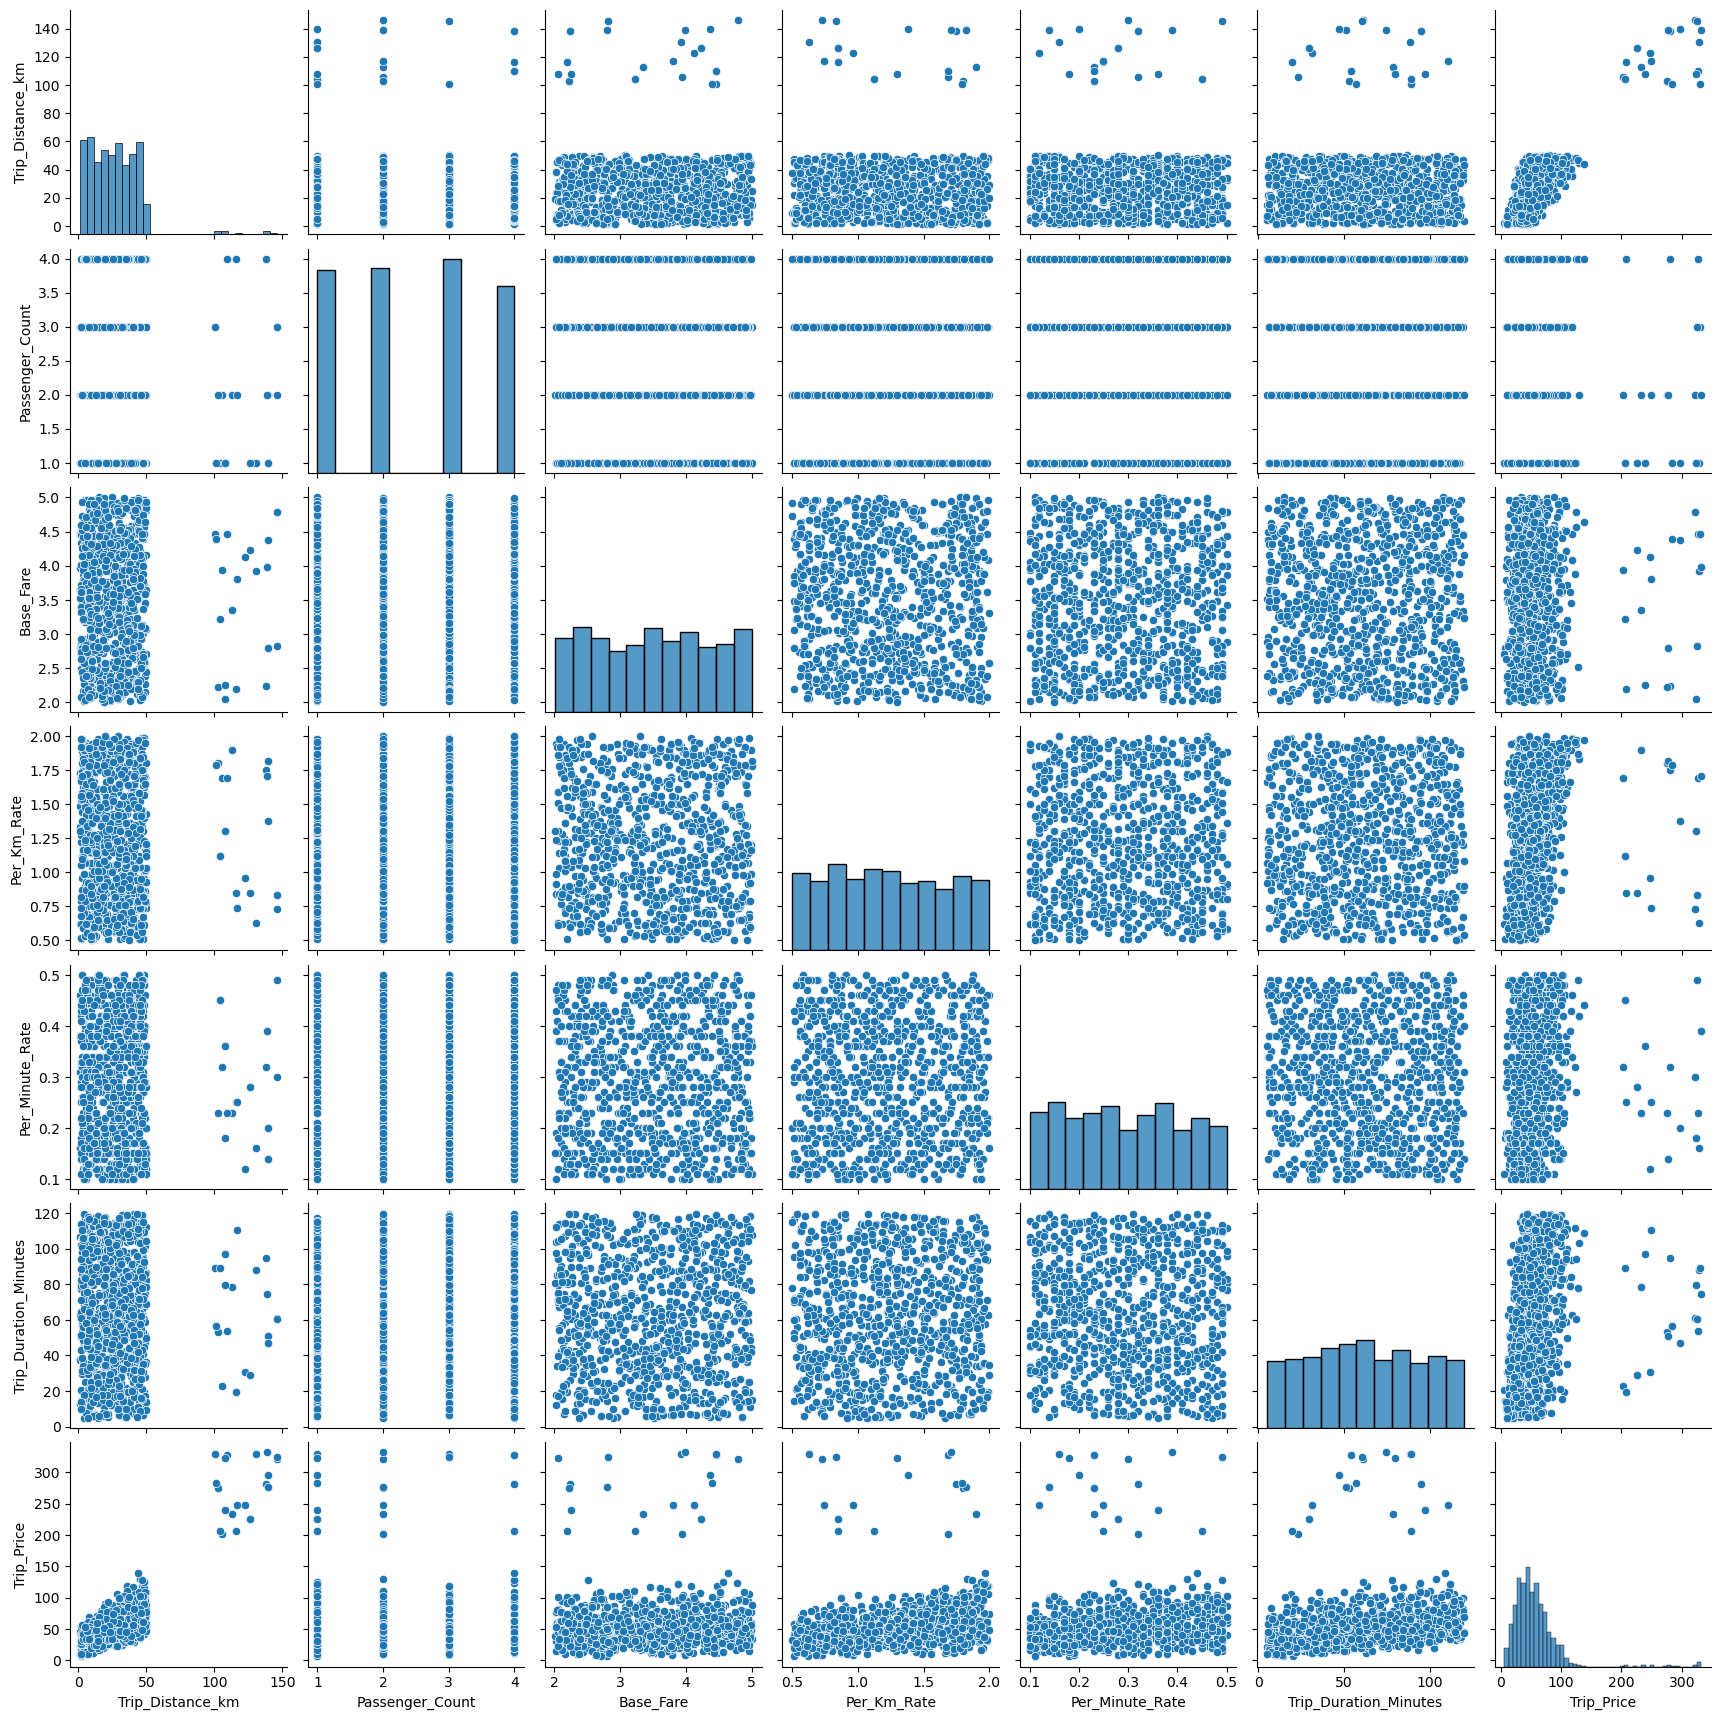

In [9]:
sns.pairplot(df)
plt.show()

In [10]:
# Drop outlier data in Trip_Distance_km
df = df[df["Trip_Distance_km"] <= 90].reset_index(drop=True)

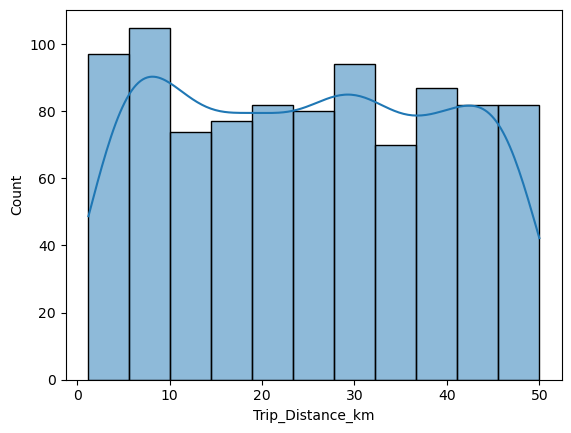

In [11]:
sns.histplot(df["Trip_Distance_km"], kde=True)
plt.show()

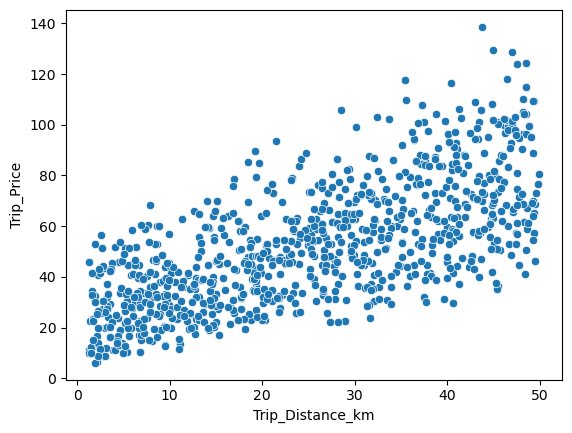

In [12]:
sns.scatterplot(data=df, x='Trip_Distance_km', y='Trip_Price')
plt.show()

In [13]:
# Drop outlier data in Trip_Price
df = df[df["Trip_Price"] <= 120].reset_index(drop=True)

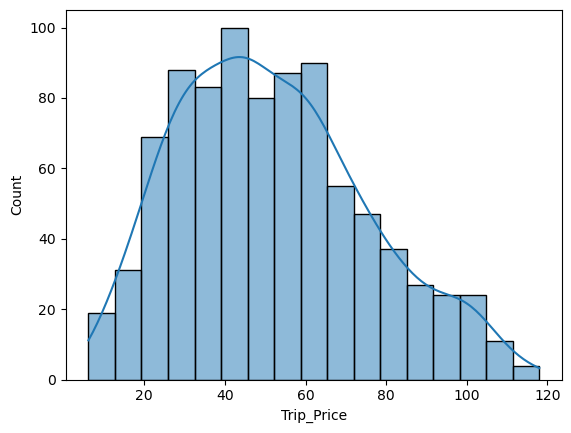

In [14]:
sns.histplot(df["Trip_Price"], kde=True)
plt.show()

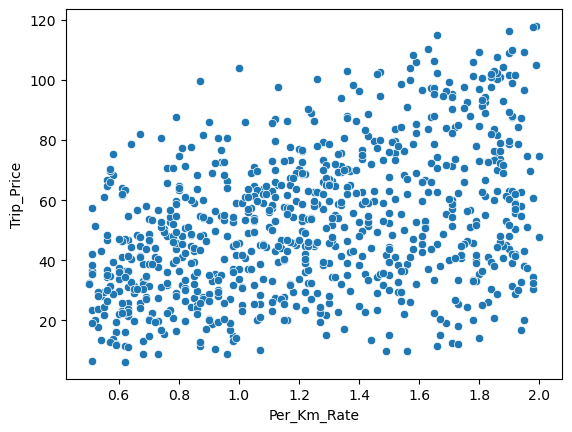

In [15]:
sns.scatterplot(x=df["Per_Km_Rate"], y=df["Trip_Price"], data=df)
plt.show()

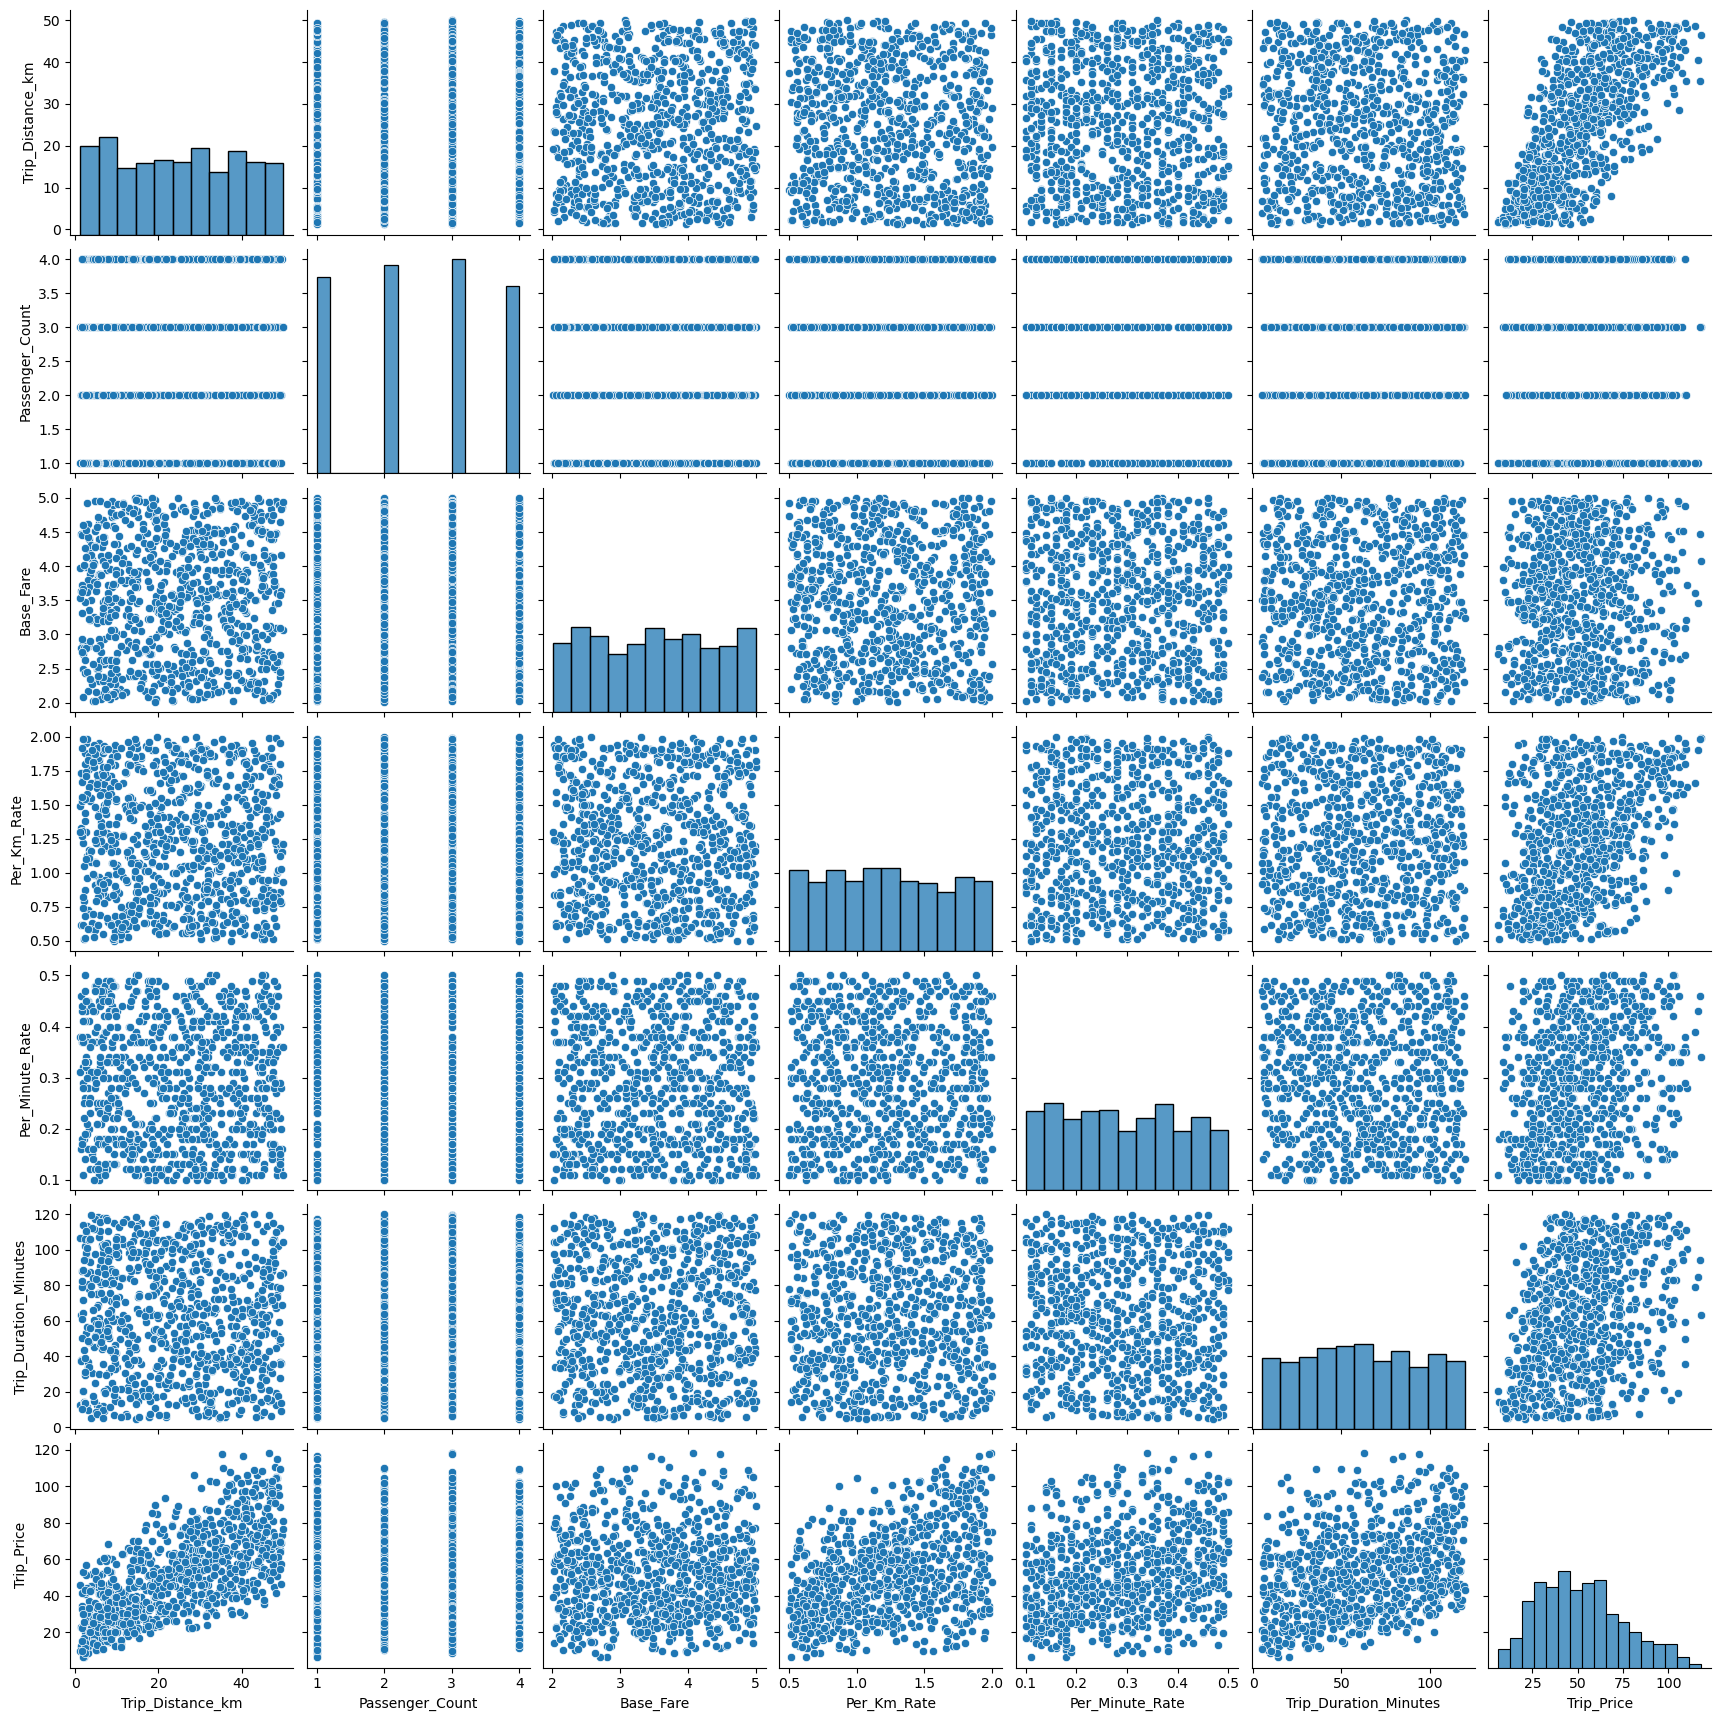

In [16]:
sns.pairplot(df)
plt.show()

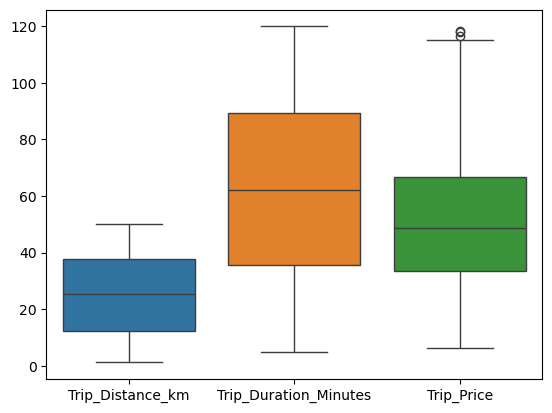

In [17]:
sns.boxplot(data=df[['Trip_Distance_km', 'Trip_Duration_Minutes', 'Trip_Price']])
plt.show()

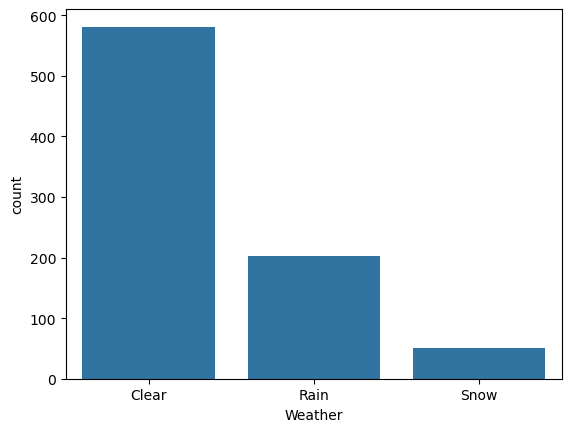

In [18]:
sns.countplot(x="Weather", data=df)
plt.show()

In [19]:
# Medyan ile doldurma
for col in ['Trip_Distance_km', 'Trip_Duration_Minutes', 'Trip_Price']:
    df[col] = df[col].fillna(df[col].median())

# Ortalama ile doldurma
for col in ['Passenger_Count', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate']:
    df[col] = df[col].fillna(df[col].mean())

# Kategorik mod ile doldurma
for col in ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [39]:
df.isnull().sum()

Trip_Distance_km         0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
Time_of_Day_Afternoon    0
Time_of_Day_Evening      0
Time_of_Day_Morning      0
Time_of_Day_Night        0
Weather_Clear            0
Weather_Rain             0
Weather_Snow             0
dtype: int64

In [21]:
print("Time Of Day:",df["Time_of_Day"].unique())
print("Day Of Week",df["Day_of_Week"].unique())
print("Traffic Conditions:",df["Traffic_Conditions"].unique())
print("Weather:",df["Weather"].unique())

Time Of Day: ['Morning' 'Evening' 'Afternoon' 'Night']
Day Of Week ['Weekday' 'Weekend']
Traffic Conditions: ['Low' 'High' 'Medium']
Weather: ['Clear' 'Rain' 'Snow']


In [22]:
# Encode Categorical Columns

# Time_of_Day : One-Hot Encoding
# Day_of_Week : Label Encoding
# Traffic_Conditions : Ordinal Encoding
# Weather : One-Hot Encoding

In [23]:
df = pd.get_dummies(df, columns=["Time_of_Day"])

df = pd.get_dummies(df, columns=['Weather'])

bool_cols = ["Time_of_Day_Afternoon", "Time_of_Day_Evening", "Time_of_Day_Morning", "Time_of_Day_Night",
             "Weather_Clear", "Weather_Rain", "Weather_Snow"]

df[bool_cols] = df[bool_cols].astype(int)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876 entries, 0 to 875
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       876 non-null    float64
 1   Day_of_Week            876 non-null    object 
 2   Passenger_Count        876 non-null    float64
 3   Traffic_Conditions     876 non-null    object 
 4   Base_Fare              876 non-null    float64
 5   Per_Km_Rate            876 non-null    float64
 6   Per_Minute_Rate        876 non-null    float64
 7   Trip_Duration_Minutes  876 non-null    float64
 8   Trip_Price             876 non-null    float64
 9   Time_of_Day_Afternoon  876 non-null    int64  
 10  Time_of_Day_Evening    876 non-null    int64  
 11  Time_of_Day_Morning    876 non-null    int64  
 12  Time_of_Day_Night      876 non-null    int64  
 13  Weather_Clear          876 non-null    int64  
 14  Weather_Rain           876 non-null    int64  
 15  Weathe

In [25]:
# target(y), features(X)

X = df.drop("Trip_Price", axis=1)
y = df["Trip_Price"]

print(X.shape,"\n")
X.head()

(876, 15) 



,Trip_Distance_km,Day_of_Week,Passenger_Count,Traffic_Conditions,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Weather_Clear,Weather_Rain,Weather_Snow
0,19.35,Weekday,3.0,Low,3.56,0.80,0.320000,53.82,0,0,1,0,1,0,0
1,36.87,Weekend,1.0,High,2.70,1.21,0.150000,37.27,0,1,0,0,1,0,0
2,30.33,Weekday,4.0,Low,3.48,0.51,0.150000,116.81,0,1,0,0,1,0,0
3,8.64,Weekend,2.0,Medium,2.55,1.71,0.480000,89.33,1,0,0,0,1,0,0
4,3.85,Weekday,4.0,High,3.51,1.66,0.291961,5.05,1,0,0,0,0,1,0


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(657, 15)
(219, 15)
(657,)
(219,)


In [27]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
label_encoder = LabelEncoder()

In [28]:
df.columns

Index(['Trip_Distance_km', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate',
       'Trip_Duration_Minutes', 'Trip_Price', 'Time_of_Day_Afternoon',
       'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night',
       'Weather_Clear', 'Weather_Rain', 'Weather_Snow'],
      dtype='object')

In [29]:
X_train['Day_of_Week'] = label_encoder.fit_transform(X_train['Day_of_Week'])
X_test['Day_of_Week'] = label_encoder.transform(X_test['Day_of_Week'])

traffic_order = [['Low', 'Medium', 'High']]
ordinal_encoder = OrdinalEncoder(categories=traffic_order)
X_train['Traffic_Conditions'] = ordinal_encoder.fit_transform(X_train[['Traffic_Conditions']])
X_test['Traffic_Conditions'] = ordinal_encoder.transform(X_test[['Traffic_Conditions']])

In [34]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 657 entries, 251 to 456
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       657 non-null    float64
 1   Day_of_Week            657 non-null    int64  
 2   Passenger_Count        657 non-null    float64
 3   Traffic_Conditions     657 non-null    float64
 4   Base_Fare              657 non-null    float64
 5   Per_Km_Rate            657 non-null    float64
 6   Per_Minute_Rate        657 non-null    float64
 7   Trip_Duration_Minutes  657 non-null    float64
 8   Time_of_Day_Afternoon  657 non-null    int64  
 9   Time_of_Day_Evening    657 non-null    int64  
 10  Time_of_Day_Morning    657 non-null    int64  
 11  Time_of_Day_Night      657 non-null    int64  
 12  Weather_Clear          657 non-null    int64  
 13  Weather_Rain           657 non-null    int64  
 14  Weather_Snow           657 non-null    int64  
dtypes: float6

In [41]:
# standardizing data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor()

In [44]:
X_train_scaled

array([[ 0.4411826 , -0.69022061, -1.38877142, ...,  0.62605843,
        -0.54157833, -0.24077171],
       [ 0.17468571, -0.69022061, -1.38877142, ...,  0.62605843,
        -0.54157833, -0.24077171],
       [ 0.12533443, -0.69022061, -0.44721576, ...,  0.62605843,
        -0.54157833, -0.24077171],
       ...,
       [-0.35478299,  1.44881214,  0.01169373, ...,  0.62605843,
        -0.54157833, -0.24077171],
       [-1.08236181,  1.44881214, -0.44721576, ...,  0.62605843,
        -0.54157833, -0.24077171],
       [-1.51594803, -0.69022061,  0.01169373, ..., -1.59729501,
         1.84645497, -0.24077171]], shape=(657, 15))

In [46]:
tree.fit(X_train_scaled, y_train)
y_pred = tree.predict(X_test_scaled)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:",mean_absolute_error(y_test, y_pred))
print("MSE:",mean_squared_error(y_test, y_pred))
print("Score:",r2_score(y_test, y_pred))

MAE: 7.177258904109589
MSE: 88.33126751264838
Score: 0.8553624028498874


In [49]:
# hyperparameter tuning

params = {
    "criterion": ["squared_error", "absolute_error"],
    "splitter": ["best", "random"],
    "max_depth": [5,15,20,None],
    "max_features": ["sqrt", "log2", None]
}

from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(estimator=DecisionTreeRegressor(), param_grid=params, cv=5)

In [50]:
grid.fit(X_train_scaled, y_train)
y_pred = grid.predict(X_test_scaled)

In [51]:
grid.best_params_

{'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'splitter': 'best'}

In [52]:
print("After Hyperparameter Tuning")
print("MAE:",mean_absolute_error(y_test, y_pred))
print("MSE:",mean_squared_error(y_test, y_pred))
print("Score:",r2_score(y_test, y_pred))

After Hyperparameter Tuning
MAE: 7.110086757990867
MSE: 86.88297227616438
Score: 0.8577339067223865
